# ISSM "square ice shelf" tutorial (with transient solution): `issm_helper` version

This notebook reproduces ISSM's square ice shelf tutorial, using `issm_helper` to streamline the workflow.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from model import model
from squaremesh import squaremesh
from issm_helper import *

## Mesh

In [2]:
lx, ly, nx, ny = 1.2e6, 1e6, 40, 40 #length in x and y (m), number of nodes in x and y

md = squaremesh(model(), lx, ly, nx, ny)
x, y = md.mesh.x, md.mesh.y

## Geometry and boundaries

Unlike the tutorial, the shelf terminates before the end of the domain. The thickness decreases linearly from the inflow boundary to the terminus.

In [3]:
x_t = 1e6 #terminus position (m)
H_max, H_min = 1000, 300 #thickness at the inflow boundary and at the terminus (m)
H_0 = H_max + (H_min - H_max)*x/x_t

Γ_inflow = (x == 0) #inflow boundary on the leftmost boundary
Γ_sidewalls = (y == 0) | (y == ly) #sidewalls on the upper and lower boundaries

## Initialize the model

As in the tutorial, the velocity is zero on the inflow boundary and the sidewalls, and the thickness is fixed on the inflow boundary. The front does not move: its advance is assumed to be exactly balanced by some form of frontal ablation.

In [4]:
md = initialize_model(md, approximation = 'SSA', temperature = 253.15,
                      thickness = H_0, ice_levelset = x - x_t, waterline = 0,
                      spcvx = dirichlet(md, (Γ_inflow | Γ_sidewalls, 0)),
                      spcvy = dirichlet(md, (Γ_inflow | Γ_sidewalls, 0)),
                      spcthickness = dirichlet(md, (Γ_inflow, H_max)),
                      moving_front = False)

## Instantaneous solution

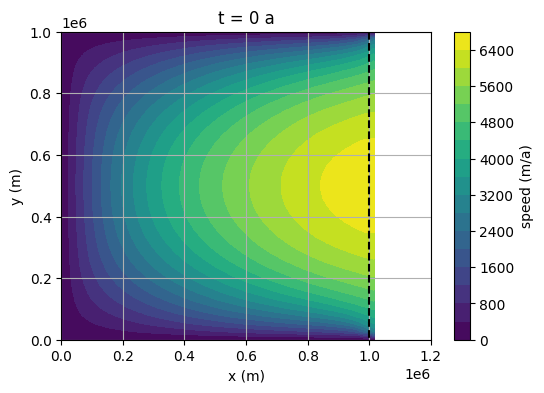

In [5]:
u = diagnostic_solve(md)

plt.figure(figsize = (6, 4))
plot_field(md, np.hypot(u[0], u[1]), label = 'speed (m/a)', title = 't = 0 a')
plt.show()

## Transient solution

In [6]:
Δt = 2 #time step (a)
model_time = 100 #a
num_steps = int(model_time/Δt)

for step in tqdm.trange(num_steps):
    u, H, s = coupled_solve(md, Δt)

100%|██████████| 50/50 [00:27<00:00,  1.85it/s]


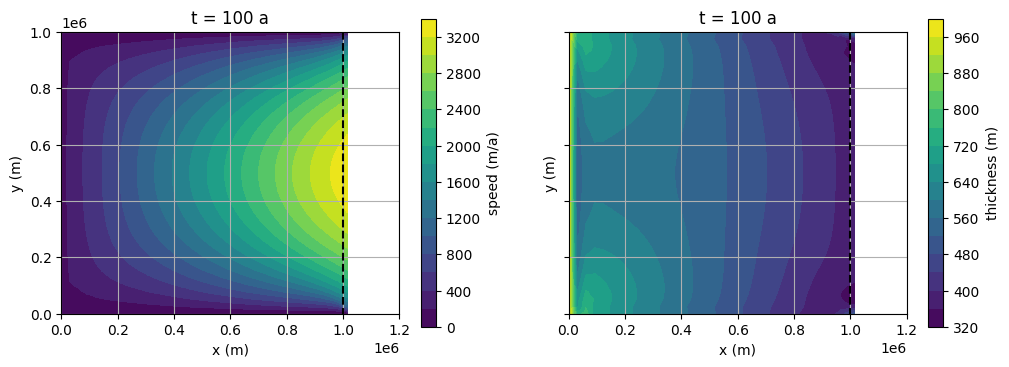

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)
plot_field(md, np.hypot(u[0], u[1]), ax = axes[0], label = 'speed (m/a)', title = f't = {model_time} a')
plot_field(md, H, ax = axes[1], label = 'thickness (m)', title = f't = {model_time} a')
plt.show()